In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, spearmanr, pearsonr

In [2]:
INPUT = "/kaggle/input/datasets/nocturnalnerd18"
OUT_DIR = "/kaggle/working/dla_cross_model"
os.makedirs(OUT_DIR, exist_ok=True)

MODELS = {
    "LLaVA-1.5-7B": {"slug": "dla-llava-analysis", "n_layer": 32, "n_head": 32, "color": "#2a78d6"},
    "Qwen2.5-VL-7B": {"slug": "dla-qwen-analysis", "n_layer": 28, "n_head": 28, "color": "#1baf7a"},
    "InternVL3-8B": {"slug": "dla-intern-analysis", "n_layer": 28, "n_head": 28, "color": "#eb6834"},
}
UNITS = ["attribute", "relation/reefknot"]
CONTRASTS = ["flip", "evidence", "evidence_matched"]
K_TOP = 20
GRID = np.linspace(0.05, 1.0, 40)

effects = {}
for name, cfg in MODELS.items():
    path = f"{INPUT}/{cfg['slug']}/effects.json"
    with open(path) as f:
        raw = json.load(f)
    n_comp = cfg["n_layer"] * cfg["n_head"] + cfg["n_layer"] + 1
    for key, rec in raw.items():
        assert len(rec["m_train"]) == n_comp, (name, key, len(rec["m_train"]))
    effects[name] = raw
    print(name, "loaded", len(raw), "unit/contrast entries")


def parse(name, unit, contrast):
    rec = effects[name].get(f"{unit}/{contrast}")
    if rec is None:
        return None
    n_layer, n_head = MODELS[name]["n_layer"], MODELS[name]["n_head"]
    h = n_layer * n_head
    m = np.array(rec["m_train"])
    return {
        "heads": m[:h].reshape(n_layer, n_head),
        "mlp": m[h:h + n_layer],
        "embed": float(m[h + n_layer]),
        "gap": float(m.sum()),
        "m": m,
        "m_held": np.array(rec["m_held"]),
        "material": set(rec["material"]),
        "n_a": rec["n_a"],
        "n_b": rec["n_b"],
        "n_layer": n_layer,
        "n_head": n_head,
    }


def comp_name(i, n_layer, n_head):
    h = n_layer * n_head
    if i < h:
        return f"L{i // n_head} H{i % n_head}"
    if i < h + n_layer:
        return f"L{i - h} MLP"
    return "embed"


def comp_depth(i, n_layer, n_head):
    h = n_layer * n_head
    if i < h:
        return (i // n_head) / n_layer
    if i < h + n_layer:
        return (i - h) / n_layer
    return 0.0

LLaVA-1.5-7B loaded 12 unit/contrast entries
Qwen2.5-VL-7B loaded 6 unit/contrast entries
InternVL3-8B loaded 6 unit/contrast entries


In [3]:
rows = []
for name in MODELS:
    for unit in UNITS:
        r = parse(name, unit, "flip")
        if r is None:
            continue
        n_layer, n_head = r["n_layer"], r["n_head"]
        gap = r["gap"]
        layer_total = r["heads"].sum(1) + r["mlp"]
        cum = r["embed"] + np.cumsum(layer_total)
        half = int(np.argmax(cum >= 0.5 * gap))
        top = int(np.argmax(r["mlp"]))
        sup = int(np.argmin(r["mlp"]))
        h = n_layer * n_head
        order = np.argsort(-r["mlp"])
        rows.append({
            "model": name, "unit": unit, "false_yes_train": r["n_a"], "gap": round(gap, 3),
            "mlp_share": round(r["mlp"].sum() / gap, 3),
            "attn_share": round(r["heads"].sum() / gap, 3),
            "embed_share": round(r["embed"] / gap, 3),
            "top_mlp": f"L{top}", "top_mlp_depth": round(top / n_layer, 2),
            "top_mlp_logits": round(r["mlp"][top], 3), "top_mlp_share": round(r["mlp"][top] / gap, 3),
            "top_mlp_held": round(r["m_held"][h + top], 3), "top_mlp_material": (h + top) in r["material"],
            "top3_mlp_share": round(r["mlp"][order[:3]].sum() / gap, 3),
            "suppressor_mlp": f"L{sup}", "suppressor_depth": round(sup / n_layer, 2),
            "suppressor_share": round(r["mlp"][sup] / gap, 3),
            "depth_50pct": round(half / n_layer, 2),
        })
summary = pd.DataFrame(rows)
print("flip contrast: where the false_yes minus true_no logit gap is written")
print(summary.to_string(index=False))

flip contrast: where the false_yes minus true_no logit gap is written
        model              unit  false_yes_train    gap  mlp_share  attn_share  embed_share top_mlp  top_mlp_depth  top_mlp_logits  top_mlp_share  top_mlp_held  top_mlp_material  top3_mlp_share suppressor_mlp  suppressor_depth  suppressor_share  depth_50pct
 LLaVA-1.5-7B         attribute             1207  3.007      0.481       0.519         -0.0     L18           0.56           2.559          0.851         2.540              True           1.261            L28              0.88            -0.431         0.56
 LLaVA-1.5-7B relation/reefknot              901  2.156      0.599       0.401         -0.0     L18           0.56           2.036          0.945         1.962              True           1.559            L28              0.88            -0.417         0.56
Qwen2.5-VL-7B         attribute               89 16.894      0.876       0.124          0.0     L23           0.82           5.863          0.347         5.

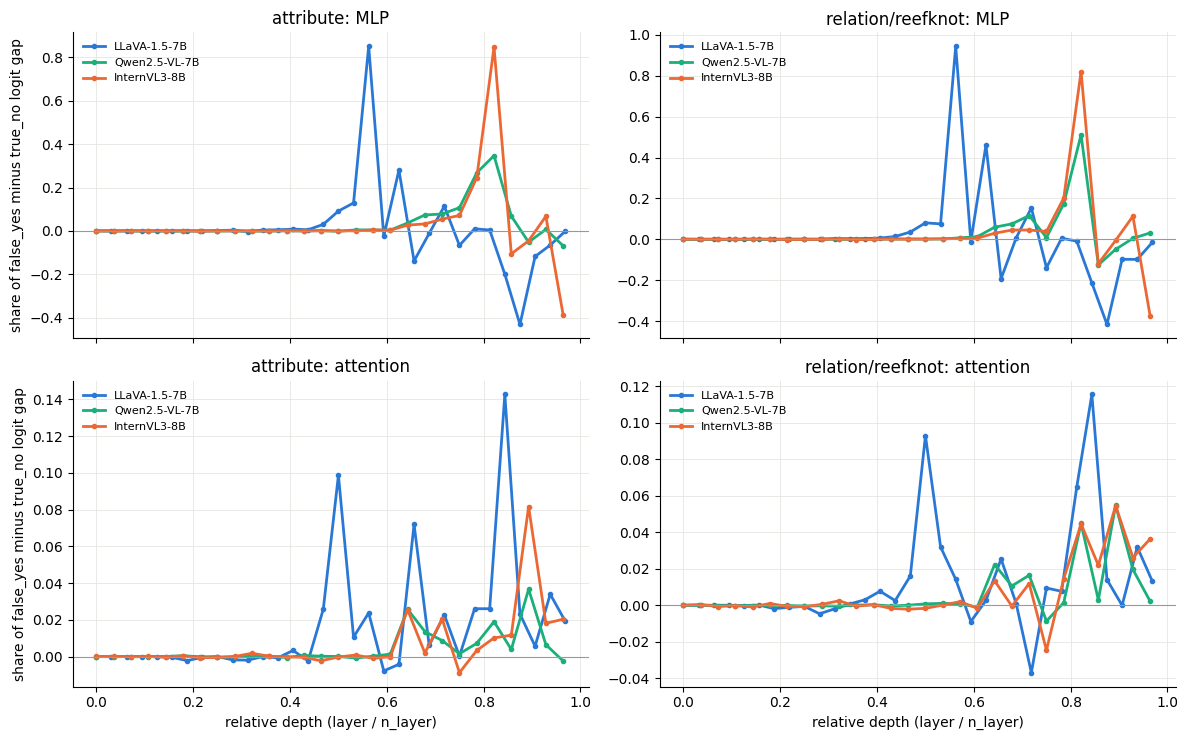

In [4]:
fig, axes = plt.subplots(2, len(UNITS), figsize=(6 * len(UNITS), 7.5), sharex=True)
for col, unit in enumerate(UNITS):
    for name, cfg in MODELS.items():
        r = parse(name, unit, "flip")
        if r is None:
            continue
        x = np.arange(r["n_layer"]) / r["n_layer"]
        axes[0, col].plot(x, r["mlp"] / r["gap"], color=cfg["color"], lw=2, marker="o", ms=3, label=name)
        axes[1, col].plot(x, r["heads"].sum(1) / r["gap"], color=cfg["color"], lw=2, marker="o", ms=3, label=name)
    for row, kind in enumerate(["MLP", "attention"]):
        ax = axes[row, col]
        ax.axhline(0, color="#999999", lw=0.8)
        ax.set_title(f"{unit}: {kind}")
        ax.grid(color="#e5e5e2", lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False, fontsize=8)
        if col == 0:
            ax.set_ylabel("share of false_yes minus true_no logit gap")
    axes[1, col].set_xlabel("relative depth (layer / n_layer)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/flip_share_by_depth.png", dpi=150)
plt.show()

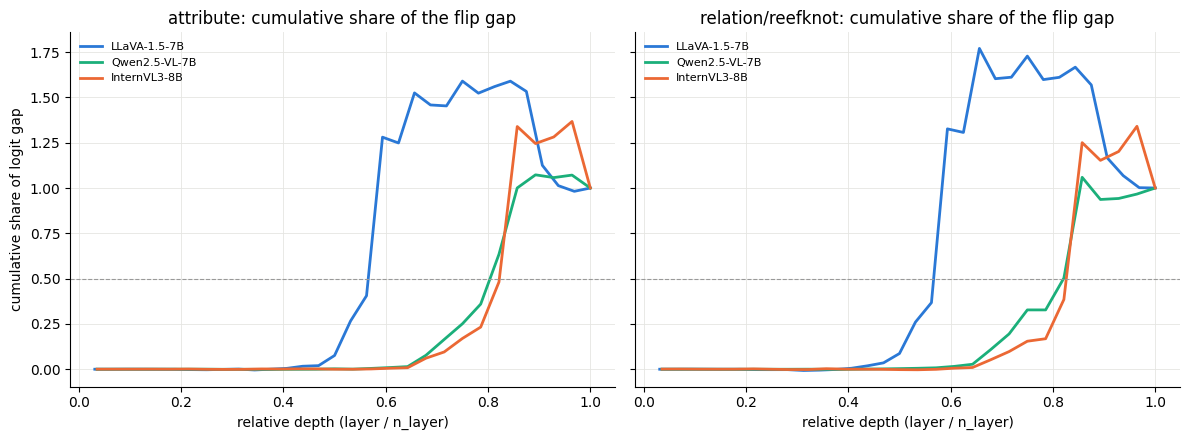

pearson correlation of cumulative-share curves on a common depth grid
attribute          LLaVA-1.5-7B    vs Qwen2.5-VL-7B   0.583
attribute          LLaVA-1.5-7B    vs InternVL3-8B    0.519
attribute          Qwen2.5-VL-7B   vs InternVL3-8B    0.989
relation/reefknot  LLaVA-1.5-7B    vs Qwen2.5-VL-7B   0.582
relation/reefknot  LLaVA-1.5-7B    vs InternVL3-8B    0.478
relation/reefknot  Qwen2.5-VL-7B   vs InternVL3-8B    0.982


In [5]:
curves = {}
fig, axes = plt.subplots(1, len(UNITS), figsize=(6 * len(UNITS), 4.5), sharey=True)
for ax, unit in zip(axes, UNITS):
    for name, cfg in MODELS.items():
        r = parse(name, unit, "flip")
        if r is None:
            continue
        cum = (r["embed"] + np.cumsum(r["heads"].sum(1) + r["mlp"])) / r["gap"]
        x = (np.arange(r["n_layer"]) + 1) / r["n_layer"]
        curves[(name, unit)] = np.interp(GRID, x, cum)
        ax.plot(x, cum, color=cfg["color"], lw=2, label=name)
    ax.axhline(0.5, color="#999999", lw=0.8, ls="--")
    ax.set_title(f"{unit}: cumulative share of the flip gap")
    ax.set_xlabel("relative depth (layer / n_layer)")
    ax.grid(color="#e5e5e2", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("cumulative share of logit gap")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/flip_cumulative.png", dpi=150)
plt.show()

names = list(MODELS)
print("pearson correlation of cumulative-share curves on a common depth grid")
for unit in UNITS:
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = curves.get((names[i], unit)), curves.get((names[j], unit))
            if a is not None and b is not None:
                print(f"{unit:18s} {names[i]:15s} vs {names[j]:15s} {pearsonr(a, b)[0]:.3f}")

In [6]:
rows = []
for name in MODELS:
    for unit in UNITS:
        for cname in ["evidence", "evidence_matched"]:
            r = parse(name, unit, cname)
            if r is None:
                continue
            n_layer, n_head = r["n_layer"], r["n_head"]
            top = int(np.argmax(np.abs(r["m"])))
            rows.append({
                "model": name, "unit": unit, "contrast": cname,
                "false_yes_train": r["n_a"], "controls_train": r["n_b"],
                "gap": round(r["gap"], 3), "material": len(r["material"]),
                "top_component": comp_name(top, n_layer, n_head),
                "top_depth": round(comp_depth(top, n_layer, n_head), 2),
                "top_train": round(r["m"][top], 3), "top_held": round(r["m_held"][top], 3),
            })
evidence = pd.DataFrame(rows)
print("evidence contrasts: false_yes against true_yes, raw and matched on the model's own confidence")
print("material counts depend on sample size and, for InternVL3, on subsampled controls")
print(evidence.to_string(index=False))

evidence contrasts: false_yes against true_yes, raw and matched on the model's own confidence
material counts depend on sample size and, for InternVL3, on subsampled controls
        model              unit         contrast  false_yes_train  controls_train    gap  material top_component  top_depth  top_train  top_held
 LLaVA-1.5-7B         attribute         evidence             1207            2460 -1.067        12       L18 MLP       0.56     -0.602    -0.613
 LLaVA-1.5-7B         attribute evidence_matched             1207            2460 -0.040         7       L20 MLP       0.62     -0.227    -0.215
 LLaVA-1.5-7B relation/reefknot         evidence              901            1337 -0.297         5       L18 MLP       0.56     -0.216    -0.214
 LLaVA-1.5-7B relation/reefknot evidence_matched              901            1337 -0.009         0       L20 MLP       0.62      0.034     0.045
Qwen2.5-VL-7B         attribute         evidence               89            1624 -0.886         4  

In [7]:
rows = []
for name in MODELS:
    for unit in UNITS:
        r = parse(name, unit, "flip")
        if r is None:
            continue
        n_layer, n_head = r["n_layer"], r["n_head"]
        h = n_layer * n_head
        top = np.argsort(-np.abs(r["heads"].ravel()))[:6]
        for i in top:
            rows.append({
                "model": name, "unit": unit, "head": comp_name(i, n_layer, n_head),
                "depth": round(comp_depth(i, n_layer, n_head), 2),
                "logits": round(r["m"][i], 3), "share": round(r["m"][i] / r["gap"], 3),
                "held": round(r["m_held"][i], 3), "material": int(i) in r["material"],
            })
heads = pd.DataFrame(rows)
print("largest single heads on the flip contrast")
print(heads.to_string(index=False))

largest single heads on the flip contrast
        model              unit    head  depth  logits  share   held  material
 LLaVA-1.5-7B         attribute  L27 H7   0.84   0.418  0.139  0.419      True
 LLaVA-1.5-7B         attribute  L16 H0   0.50   0.248  0.082  0.251      True
 LLaVA-1.5-7B         attribute L21 H14   0.66   0.107  0.036  0.103      True
 LLaVA-1.5-7B         attribute L30 H31   0.94   0.101  0.033  0.102      True
 LLaVA-1.5-7B         attribute L21 H25   0.66   0.095  0.032  0.096      True
 LLaVA-1.5-7B         attribute  L28 H7   0.88   0.078  0.026  0.082      True
 LLaVA-1.5-7B relation/reefknot  L27 H7   0.84   0.239  0.111  0.237      True
 LLaVA-1.5-7B relation/reefknot  L16 H0   0.50   0.147  0.068  0.156      True
 LLaVA-1.5-7B relation/reefknot  L26 H3   0.81   0.106  0.049  0.097      True
 LLaVA-1.5-7B relation/reefknot L30 H31   0.94   0.077  0.036  0.076      True
 LLaVA-1.5-7B relation/reefknot L23 H10   0.72  -0.064 -0.030 -0.065      True
 LLaVA-1.5

In [8]:
rows = []
for name in MODELS:
    for cname in CONTRASTS:
        a, b = parse(name, "attribute", cname), parse(name, "relation/reefknot", cname)
        if a is None or b is None:
            continue
        n_comp = len(a["m"])
        top_a, top_b = set(np.argsort(-np.abs(a["m"]))[:K_TOP]), set(np.argsort(-np.abs(b["m"]))[:K_TOP])
        overlap = len(top_a & top_b)
        rows.append({
            "model": name, "contrast": cname, "top20_overlap": overlap,
            "p": float(hypergeom.sf(overlap - 1, n_comp, K_TOP, K_TOP)),
            "spearman_logits": round(spearmanr(a["m"], b["m"])[0], 3),
            "spearman_abs": round(spearmanr(np.abs(a["m"]), np.abs(b["m"]))[0], 3),
        })
within = pd.DataFrame(rows)
print("attribute against relation/reefknot within each model")
print(within.to_string(index=False))

attribute against relation/reefknot within each model
        model         contrast  top20_overlap            p  spearman_logits  spearman_abs
 LLaVA-1.5-7B             flip             16 2.234873e-28            0.533         0.769
 LLaVA-1.5-7B         evidence             14 6.362336e-23            0.276         0.739
 LLaVA-1.5-7B evidence_matched             11 6.002916e-16            0.020         0.712
Qwen2.5-VL-7B             flip             17 1.827400e-29            0.348         0.725
Qwen2.5-VL-7B         evidence             11 1.070255e-14            0.086         0.566
Qwen2.5-VL-7B evidence_matched              8 2.954267e-09           -0.032         0.534
 InternVL3-8B             flip             17 1.827400e-29            0.540         0.700
 InternVL3-8B         evidence             13 5.740197e-19            0.326         0.637
 InternVL3-8B evidence_matched              9 6.014064e-11           -0.123         0.618


In [9]:
summary.to_json(f"{OUT_DIR}/flip_summary.json", orient="records", indent=1)
evidence.to_json(f"{OUT_DIR}/evidence_summary.json", orient="records", indent=1)
heads.to_json(f"{OUT_DIR}/top_heads.json", orient="records", indent=1)
within.to_json(f"{OUT_DIR}/within_model_overlap.json", orient="records", indent=1)

USERNAME = "nocturnalnerd18"
with open(os.path.join(OUT_DIR, "dataset-metadata.json"), "w") as f:
    json.dump({
        "title": "dla-cross-model",
        "id": f"{USERNAME}/dla-cross-model",
        "subtitle": "Cross-model comparison of DLA hallucination effects",
        "description": "Summary tables and figures comparing direct logit attribution effects for LLaVA-1.5-7B, Qwen2.5-VL-7B and InternVL3-8B "
                       "on attribute and relation/reefknot questions, built from the dla-*-analysis datasets. flip_summary.json holds the "
                       "dominant MLP, suppressor and depth at which half of the false_yes minus true_no gap is written, by relative depth. "
                       "evidence_summary.json holds the raw and confidence-matched evidence contrasts, top_heads.json the largest heads and "
                       "within_model_overlap.json the attribute against relation top-20 overlaps.",
        "licenses": [{"name": "CC0-1.0"}],
    }, f)

!kaggle datasets create -p {OUT_DIR}

Starting upload for file flip_summary.json
100%|██████████████████████████████████████| 2.57k/2.57k [00:00<00:00, 6.79kB/s]
Upload successful: flip_summary.json (3KB)
Starting upload for file top_heads.json
100%|██████████████████████████████████████| 5.81k/5.81k [00:00<00:00, 15.5kB/s]
Upload successful: top_heads.json (6KB)
Starting upload for file within_model_overlap.json
100%|██████████████████████████████████████| 1.34k/1.34k [00:00<00:00, 3.64kB/s]
Upload successful: within_model_overlap.json (1KB)
Starting upload for file flip_cumulative.png
100%|█████████████████████████████████████████| 112k/112k [00:00<00:00, 216kB/s]
Upload successful: flip_cumulative.png (112KB)
Starting upload for file evidence_summary.json
100%|██████████████████████████████████████| 3.06k/3.06k [00:00<00:00, 8.36kB/s]
Upload successful: evidence_summary.json (3KB)
Starting upload for file flip_share_by_depth.png
100%|█████████████████████████████████████████| 264k/264k [00:00<00:00, 368kB/s]
Upload succ